<h3 style='color:red'>Statistical Analysis and Linear Algebra Application in DataScience Project</h3>

<h3 style='color:blue'>Student Performance & Stress Analysis</h3>

**This project analyzes factors affecting student performance (CGPA) using EDA, statistical tests, PCA, and linear algebra regression.**

In [3]:
# import necessary libraries

import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns

from scipy import stats

from sklearn.decomposition import PCA

from sklearn.preprocessing import StandardScaler

In [17]:
# loading dataset

df = pd.read_csv('Student_Performance.csv')

df

,student_id,age,study_hours_per_week,sleep_hours,cgpa,stress_level,part_time_job,gender,attendance_pct,social_media_hours
0,1,24,25.2,7.3,6.05,3,No,Female,87.9,1.9
1,2,21,21.2,9.0,6.86,2,No,Female,100.0,1.9
2,3,22,NaN,NaN,7.61,1,No,Male,93.7,2.9
3,4,24,17.9,7.3,8.04,4,No,Male,81.7,1.9
4,5,20,9.7,7.4,5.56,1,No,Female,97.0,1.6
...,...,...,...,...,...,...,...,...,...,...
95,96,23,30.8,8.0,6.82,2,No,Female,85.6,8.3
96,97,19,14.5,4.0,6.01,1,Yes,Male,85.1,4.0
97,98,21,17.7,7.3,6.61,4,Yes,Male,84.8,18.0
98,99,23,70.0,6.0,NaN,4,No,Male,87.0,1.3


<h3 style='color:red'>Data Cleaning</h3>

In [20]:
# df.info() gives a summary of the dataset including column names, data types, and missing values.

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            100 non-null    int64  
 1   age                   100 non-null    int64  
 2   study_hours_per_week  95 non-null     float64
 3   sleep_hours           95 non-null     float64
 4   cgpa                  95 non-null     float64
 5   stress_level          100 non-null    int64  
 6   part_time_job         100 non-null    object 
 7   gender                100 non-null    object 
 8   attendance_pct        100 non-null    float64
 9   social_media_hours    100 non-null    float64
dtypes: float64(5), int64(3), object(2)
memory usage: 7.9+ KB


In [114]:
# df.describe() gives summary statistics (mean, median, std, min, max, quartiles) for numerical columns.

df.describe()

,student_id,age,study_hours_per_week,sleep_hours,cgpa,stress_level,attendance_pct,social_media_hours
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,50.500000,21.600000,20.760000,7.117000,7.066800,3.150000,85.200000,3.133000
std,29.011492,2.146173,10.061468,1.300432,1.105617,1.290016,9.834509,2.674196
min,1.000000,18.000000,1.700000,4.000000,3.110000,1.000000,58.000000,0.000000
25%,25.750000,20.000000,16.225000,6.000000,6.290000,2.000000,80.125000,1.475000
50%,50.500000,21.000000,19.700000,7.300000,7.030000,3.000000,85.600000,2.900000
75%,75.250000,23.000000,23.375000,7.925000,7.797500,4.000000,92.625000,4.250000
max,100.000000,25.000000,80.000000,10.000000,9.560000,5.000000,100.000000,18.000000


In [118]:
# df.duplicated().sum() gives the total number of duplicate rows in the dataset.

df.duplicated().sum()

0

In [26]:
# Checking missing values

df.isnull().sum()

student_id              0
age                     0
study_hours_per_week    5
sleep_hours             5
cgpa                    5
stress_level            0
part_time_job           0
gender                  0
attendance_pct          0
social_media_hours      0
dtype: int64

In [110]:
# filling missing values (imputation)

df['cgpa'] = df['cgpa'].fillna(df['cgpa'].median())

df['sleep_hours'] = df['sleep_hours'].fillna(df['sleep_hours'].median())

df['study_hours_per_week'] = df['study_hours_per_week'].fillna(df['study_hours_per_week'].median())

In [30]:
# re-checking wether any missing values exist 

df.isnull().sum()

student_id              0
age                     0
study_hours_per_week    0
sleep_hours             0
cgpa                    0
stress_level            0
part_time_job           0
gender                  0
attendance_pct          0
social_media_hours      0
dtype: int64

<h3 style='color:red'>Exploratory Data Analysis</h3>

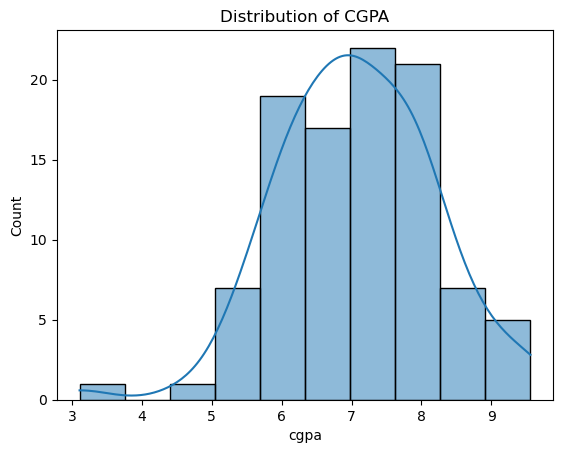

In [74]:
# we explore distributions and relationship between variables

# Distribution of CGPA
sns.histplot(df['cgpa'], bins=10, kde=True)

plt.title("Distribution of CGPA")

plt.show()

In [149]:
# Most students have CGPA between 6–8.

**Scatter Plot: Attendance vs CGPA**

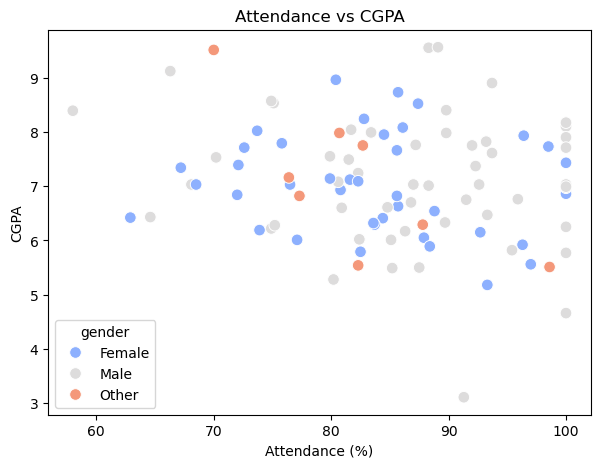

In [83]:
plt.figure(figsize=(7,5))

sns.scatterplot(x="attendance_pct", y="cgpa", hue="gender", data=df, palette="coolwarm", s=70)

plt.title("Attendance vs CGPA")

plt.xlabel("Attendance (%)")

plt.ylabel("CGPA")

plt.show()

In [80]:
# higher attendance tends to align with higher CGPA, but the relationship is not perfectly linear.

**Box Plot: Stress Level vs CGPA**

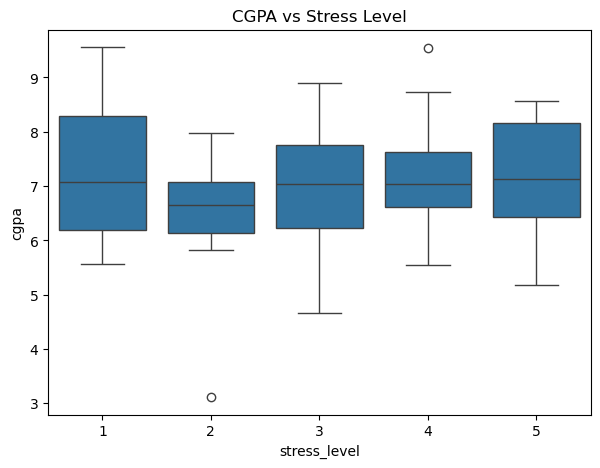

In [41]:
plt.figure(figsize=(7,5))

sns.boxplot(x="stress_level", y="cgpa", data=df)

plt.title("CGPA vs Stress Level")

plt.show()

In [43]:
# Students with low stress (level 1–2) show slightly higher median CGPA than students at higher stress levels.

# Outliers exist (e.g., very low CGPA in stress level 2, very high CGPA in stress level 4).

**Bar Plot of Average CGPA by Stress Level**

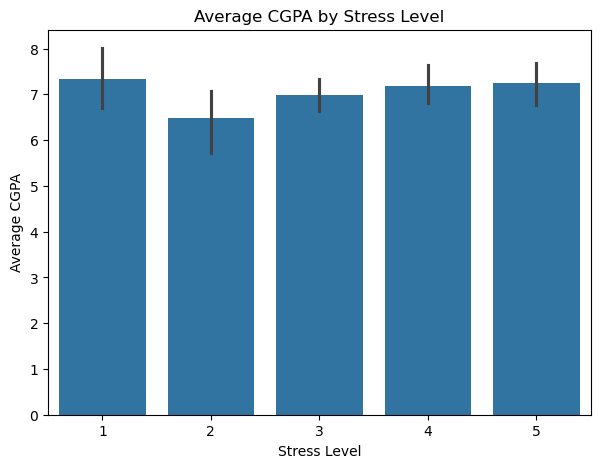

In [124]:
plt.figure(figsize=(7,5))

sns.barplot(x='stress_level', y='cgpa', data=df)

plt.title("Average CGPA by Stress Level")

plt.xlabel("Stress Level")

plt.ylabel("Average CGPA")

plt.show()

In [127]:
# Students with lower stress levels (1) tend to have slightly higher CGPA on average compared to those with moderate stress levels (2), 
# while very high stress levels (4,5) do not show major differences.

**Line Plot: Study Hours vs Average CGPA**

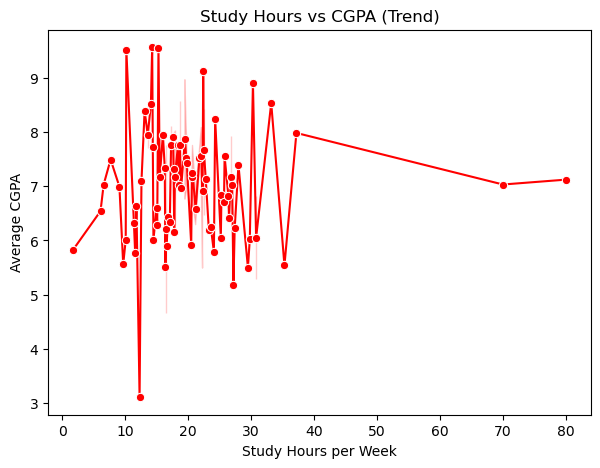

In [133]:
plt.figure(figsize=(7,5))

sns.lineplot(x='study_hours_per_week', y='cgpa', data=df, marker='o', color="red")

plt.title("Study Hours vs CGPA (Trend)")

plt.xlabel("Study Hours per Week")

plt.ylabel("Average CGPA")

plt.show()

In [135]:
# CGPA values remain scattered across different study hours with no clear upward trend.

<h3 style='color:red'>Statistical Tests </h4>

**T-Tsest**

In [147]:
job_yes = df[df['part_time_job']=="Yes"]['cgpa']

job_no = df[df['part_time_job']=="No"]['cgpa']

stats.ttest_ind(job_yes, job_no)

TtestResult(statistic=-0.11283122361849188, pvalue=0.9103951693423467, df=98.0)

In [48]:
# The independent t-test shows no significant difference in CGPA between students with and without part-time jobs (p = 0.91). 

# This suggests that part-time jobs do not affect academic performance in this sample.”

**One-Way ANOVA**

In [95]:
low = df[df["stress_level"] == 1]["cgpa"]

medium = df[df["stress_level"] == 2]["cgpa"]

high = df[df["stress_level"] == 3]["cgpa"]

f_stat, p_val = stats.f_oneway(low, medium, high)

print("Scipy ANOVA Results:")

print("F-statistic:", f_stat, " P-value:", p_val)

Scipy ANOVA Results:
F-statistic: 1.8354832165617285  P-value: 0.16852944186105756


In [139]:
# p ≈ 0.91, meaning part-time jobs did not affect academic performance in this sample.

<h3 style='color:red'>Linear Algebra Application</h3>

**Principal Component Analysis of Numerical Features**

In [151]:
numeric_cols = ['age', 'study_hours_per_week', 'sleep_hours',
                'cgpa', 'stress_level', 'attendance_pct',
                'social_media_hours']

df_num = df[numeric_cols]

# Standardize (important for PCA)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df_num)

# Apply PCA

pca = PCA(n_components=None)   # keep all PCs

X_pca = pca.fit_transform(X_scaled)

# Explained variance

print("Explained variance ratio:", pca.explained_variance_ratio_)

print("Cumulative variance explained:", pca.explained_variance_ratio_.cumsum())

Explained variance ratio: [0.19316875 0.18346009 0.16168734 0.14252433 0.12870235 0.10107232
 0.08938482]
Cumulative variance explained: [0.19316875 0.37662884 0.53831618 0.68084052 0.80954286 0.91061518
 1.        ]


In [141]:
# dataset’s variance is spread across multiple components rather than being dominated by a single one.

**Linear Regression**

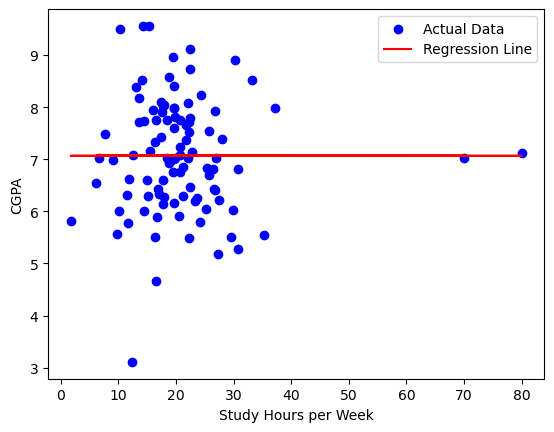

Intercept: 7.066936299849932
Slope: [-6.56550337e-06]


In [143]:
from sklearn.linear_model import LinearRegression

# Take one feature (study hours) and target (CGPA)

X = df[['study_hours_per_week']]   # Independent variable

y = df['cgpa']                     # Dependent variable



# Fit Linear Regression

model = LinearRegression()

model.fit(X, y)

# Predictions

y_pred = model.predict(X)

# Plot

plt.scatter(X, y, color='blue', label="Actual Data")

plt.plot(X, y_pred, color='red', label="Regression Line")

plt.xlabel("Study Hours per Week")

plt.ylabel("CGPA")

plt.legend()

plt.show()

# Print coefficients

print("Intercept:", model.intercept_)

print("Slope:", model.coef_)


In [145]:
# Increasing study hours per week does not show a strong or consistent impact on CGPA